In [331]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import norm, rankdata, mannwhitneyu, t as t_dist

SPREADS_PATH = '../output/results/final results/complete_results_weekly_15_dampening.csv'
DATE_COL     = 'date'
COUNTRY_COL  = 'country'
CDS_COL      = 'cds_spread'
EXPORTERS    = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia',
                'Mexico', 'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS     = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
                'South Korea', 'Thailand', 'Turkey']
DD_COLS = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

panel = pd.read_csv(SPREADS_PATH, parse_dates=[DATE_COL])
panel['exporter'] = panel[COUNTRY_COL].isin(EXPORTERS).astype(int)

In [332]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import norm, rankdata, mannwhitneyu, t as t_dist
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.stats.stattools import durbin_watson

DATE_COL     = 'date'
COUNTRY_COL  = 'country'
CDS_COL      = 'cds_spread'
EXPORTERS    = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia',
                'Mexico', 'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS     = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
                'South Korea', 'Thailand', 'Turkey']
DD_COLS = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

panel = pd.read_csv(SPREADS_PATH, parse_dates=[DATE_COL])
panel['exporter'] = panel[COUNTRY_COL].isin(EXPORTERS).astype(int)

# ── Margins ───────────────────────────────────────────────────
def country_margins(cds, dd):
    ln_cds = np.log(cds)
    u = norm.cdf(ln_cds, ln_cds.mean(), ln_cds.std())
    neg_dd = -dd
    v = norm.cdf(neg_dd, neg_dd.mean(), neg_dd.std())
    return np.clip(u, 1e-25, 1-1e-25), np.clip(v, 1e-25, 1-1e-25)

def country_margins_ecdf(cds, dd):
    ecdf_cds = ECDF(cds)
    ecdf_dd = ECDF(-dd)
    u = np.clip(ecdf_cds(cds), 1e-6, 1-1e-6)
    v = np.clip(ecdf_dd(-dd), 1e-6, 1-1e-6)
    return u, v

def joe_logpdf(u, v, theta):
    u, v = np.clip(u, 1e-10, 1-1e-10), np.clip(v, 1e-10, 1-1e-10)
    u_bar = 1 - u
    v_bar = 1 - v
    A = u_bar**theta + v_bar**theta - u_bar**theta * v_bar**theta
    t1 = np.log(theta - 1)
    t2 = (theta - 1) * (np.log(u_bar) + np.log(v_bar))
    t3 = (1/theta - 2) * np.log(A)
    t4 = np.log(u_bar**(theta-1) + v_bar**(theta-1) - u_bar**(theta-1) * v_bar**(theta-1))
    return t1 + t2 + t3 + t4

def fit_joe(u, v):
    def obj(t):
        if t < 1.001: return 1e10
        return -np.sum(joe_logpdf(u, v, t))
    return minimize(obj, [2.0], method='Nelder-Mead').x[0]

# ── Copula densities ──────────────────────────────────────────
def student_t_logpdf(u, v, rho, df_val):
    x, y = t_dist.ppf(u, df_val), t_dist.ppf(v, df_val)
    rho_sq = rho**2
    num = (1 + (x**2 + y**2 - 2*rho*x*y) / (df_val * (1 - rho_sq)))**(-(df_val + 2) / 2)
    den = (1 + x**2 / df_val)**(-(df_val + 1) / 2) * (1 + y**2 / df_val)**(-(df_val + 1) / 2)
    return np.log(num / (den * np.sqrt(1 - rho_sq)))

def clayton_logpdf(u, v, theta):
    u, v = np.clip(u, 1e-10, 1-1e-10), np.clip(v, 1e-10, 1-1e-10)
    term1 = np.log(theta + 1)
    term2 = -(theta + 1) * np.log(u * v)
    term3 = -(2 + 1/theta) * np.log(u**(-theta) + v**(-theta) - 1)
    return term1 + term2 + term3

# ── Fitting ───────────────────────────────────────────────────
def fit_t_copula(u, v):
    def obj(p):
        r, n = p
        if not (-0.99 < r < 0.99) or not (2.1 < n < 50): return 1e10
        return -np.sum(student_t_logpdf(u, v, r, n))
    return minimize(obj, [np.corrcoef(u, v)[0,1], 5.0], method='Nelder-Mead').x

def fit_clayton(u, v):
    def obj(t):
        if t < 0.01: return 1e10
        return -np.sum(clayton_logpdf(u, v, t))
    return minimize(obj, [2.0], method='Nelder-Mead').x[0]

def gaussian_logpdf(u, v, rho):
    x, y = norm.ppf(u), norm.ppf(v)
    rho_sq = rho**2
    return -0.5 * (np.log(1 - rho_sq) + (rho_sq * (x**2 + y**2) - 2*rho*x*y) / (1 - rho_sq))

def fit_gaussian(u, v):
    def obj(r):
        if not (-0.99 < r < 0.99): return 1e10
        return -np.sum(gaussian_logpdf(u, v, r))
    return minimize(obj, [np.corrcoef(u, v)[0,1]], method='Nelder-Mead').x[0]


def gumbel_logpdf(u, v, theta):
    u, v = np.clip(u, 1e-10, 1-1e-10), np.clip(v, 1e-10, 1-1e-10)
    lu, lv = -np.log(u), -np.log(v)
    A = (lu**theta + lv**theta)**(1/theta)
    t1 = -A
    t2 = (theta - 1) * (np.log(lu) + np.log(lv))
    t3 = -np.log(u) - np.log(v)
    t4 = (1/theta - 2) * np.log(lu**theta + lv**theta)
    t5 = np.log(A + theta - 1)
    return t1 + t2 + t3 + t4 + t5

def fit_gumbel(u, v):
    def obj(t):
        if t < 1.001: return 1e10
        return -np.sum(gumbel_logpdf(u, v, t))
    return minimize(obj, [2.0], method='Nelder-Mead').x[0]

def run_test(target_model, copula_type):
    m0_col, mx_col = DD_COLS['M0'], DD_COLS[target_model]
    df = panel[[DATE_COL, COUNTRY_COL, CDS_COL, m0_col, mx_col, 'exporter']].dropna()
    df = df[df[CDS_COL] > 0].copy()
    df['d_loglik'] = np.nan

    for country in df[COUNTRY_COL].unique():
        mask = df[COUNTRY_COL] == country
        sub = df[mask]

        cds = sub[CDS_COL].values
        dd0 = sub[m0_col].values
        dd1 = sub[mx_col].values

        u, v0 = country_margins_ecdf(cds, dd0)
        u, v1 = country_margins_ecdf(cds, dd1)

        if copula_type == 'student':
            p0 = fit_t_copula(u, v0)
            p1 = fit_t_copula(u, v1)
            ll0 = student_t_logpdf(u, v0, p0[0], p0[1])
            ll1 = student_t_logpdf(u, v1, p1[0], p1[1])

        elif copula_type == 'clayton':
            u_c = np.clip(1 - u, 1e-25, 1-1e-25)
            v0_c = np.clip(1 - v0, 1e-25, 1-1e-25)
            v1_c = np.clip(1 - v1, 1e-25, 1-1e-25)
            t0 = fit_clayton(u_c, v0_c)
            t1 = fit_clayton(u_c, v1_c)
            ll0 = clayton_logpdf(u_c, v0_c, t0)
            ll1 = clayton_logpdf(u_c, v1_c, t1)

        elif copula_type == 'gaussian':
            r0 = fit_gaussian(u, v0)
            r1 = fit_gaussian(u, v1)
            ll0 = gaussian_logpdf(u, v0, r0)
            ll1 = gaussian_logpdf(u, v1, r1)

        elif copula_type == 'gumbel':
            t0 = fit_gumbel(u, v0)
            t1 = fit_gumbel(u, v1)
            ll0 = gumbel_logpdf(u, v0, t0)
            ll1 = gumbel_logpdf(u, v1, t1)

        elif copula_type == 'joe':
            t0 = fit_joe(u, v0)
            t1 = fit_joe(u, v1)
            ll0 = joe_logpdf(u, v0, t0)
            ll1 = joe_logpdf(u, v1, t1)

        df.loc[mask, 'd_loglik'] = ll1 - ll0

    clean = df.dropna(subset=['d_loglik'])
    q = clean['d_loglik'].quantile([0.001, 0.999])
    clean['d_loglik'] = clean['d_loglik'].clip(q[0.001], q[0.999])
    X = sm.add_constant(clean['exporter'])
    res = sm.OLS(clean['d_loglik'], X).fit(cov_type='HAC', cov_kwds={'maxlags': None})
    return res

for model, cop in [('M1', 'gaussian'), ('M2', 'gaussian'), ('M1', 'gumbel'), ('M2', 'gumbel'), ('M1', 'clayton'), ('M2', 'clayton'), ('M1', 'student'), ('M2', 'student')]:
    res = run_test(model, cop)
    print(f"\n{model} ({cop}):")
    print(f"  Gamma (Universal): {res.params['const']:.4f} (p={res.pvalues['const']:.4f})")
    print(f"  Delta (Exporter):  {res.params['exporter']:.4f} (p={res.pvalues['exporter']:.4f})")


M1 (gaussian):
  Gamma (Universal): 0.0103 (p=0.5944)
  Delta (Exporter):  0.0617 (p=0.0177)

M2 (gaussian):
  Gamma (Universal): -0.0104 (p=0.3695)
  Delta (Exporter):  0.0609 (p=0.0017)

M1 (gumbel):
  Gamma (Universal): 0.0305 (p=0.1273)
  Delta (Exporter):  0.0604 (p=0.0292)

M2 (gumbel):
  Gamma (Universal): 0.0057 (p=0.6568)
  Delta (Exporter):  0.0483 (p=0.0238)

M1 (clayton):
  Gamma (Universal): 0.0299 (p=0.0897)
  Delta (Exporter):  0.0663 (p=0.0097)

M2 (clayton):
  Gamma (Universal): 0.0048 (p=0.6920)
  Delta (Exporter):  0.0523 (p=0.0099)

M1 (student):
  Gamma (Universal): 0.0128 (p=0.5143)
  Delta (Exporter):  0.0582 (p=0.0265)

M2 (student):
  Gamma (Universal): -0.0083 (p=0.4780)
  Delta (Exporter):  0.0574 (p=0.0036)


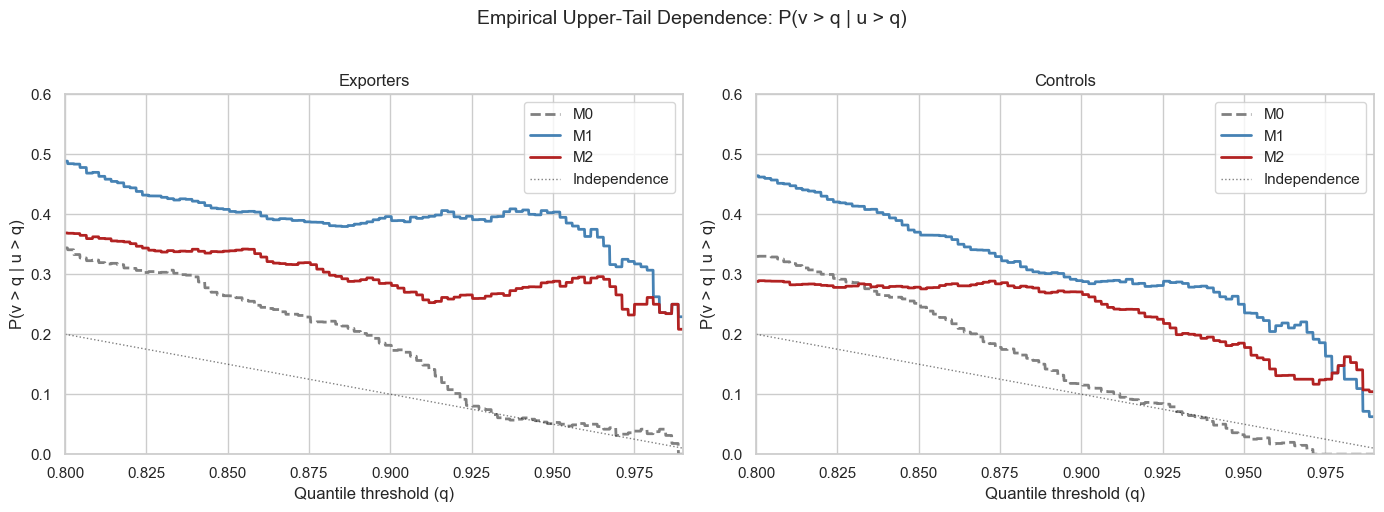

In [333]:
thresholds = np.arange(0.80, 0.99, 0.0001)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Empirical Upper-Tail Dependence: P(v > q | u > q)', fontsize=14, y=1.02)

for ax_idx, (grp_name, countries) in enumerate([('Exporters', EXPORTERS), ('Controls', CONTROLS)]):
    ax = axes[ax_idx]
    
    for model, dd_col, color, ls in [('M0', 'DD_M0', 'grey', '--'),
                                      ('M1', 'DD_M1', 'steelblue', '-'),
                                      ('M2', 'DD_M2', 'firebrick', '-')]:
        all_u, all_v = [], []
        for country in countries:
            sub = panel[panel[COUNTRY_COL] == country][[CDS_COL, dd_col]].dropna()
            sub = sub[sub[CDS_COL] > 0].copy()
            u, v = country_margins_ecdf(sub[CDS_COL].values, sub[dd_col].values)
            all_u.extend(u)
            all_v.extend(v)
        
        u_arr, v_arr = np.array(all_u), np.array(all_v)
        
        hit_rates = []
        for q in thresholds:
            mask_u = u_arr > q
            if mask_u.sum() > 0:
                hit_rate = (v_arr[mask_u] > q).mean()
            else:
                hit_rate = np.nan
            hit_rates.append(hit_rate)
        
        ax.plot(thresholds, hit_rates, color=color, ls=ls, lw=2, label=model)
    
    # independence baseline
    ax.plot(thresholds, 1 - thresholds, color='black', ls=':', lw=1, alpha=0.5, label='Independence')
    
    ax.set_xlabel('Quantile threshold (q)')
    ax.set_ylabel('P(v > q | u > q)')
    ax.set_title(grp_name)
    ax.legend()
    ax.set_xlim(0.80, 0.99)
    ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

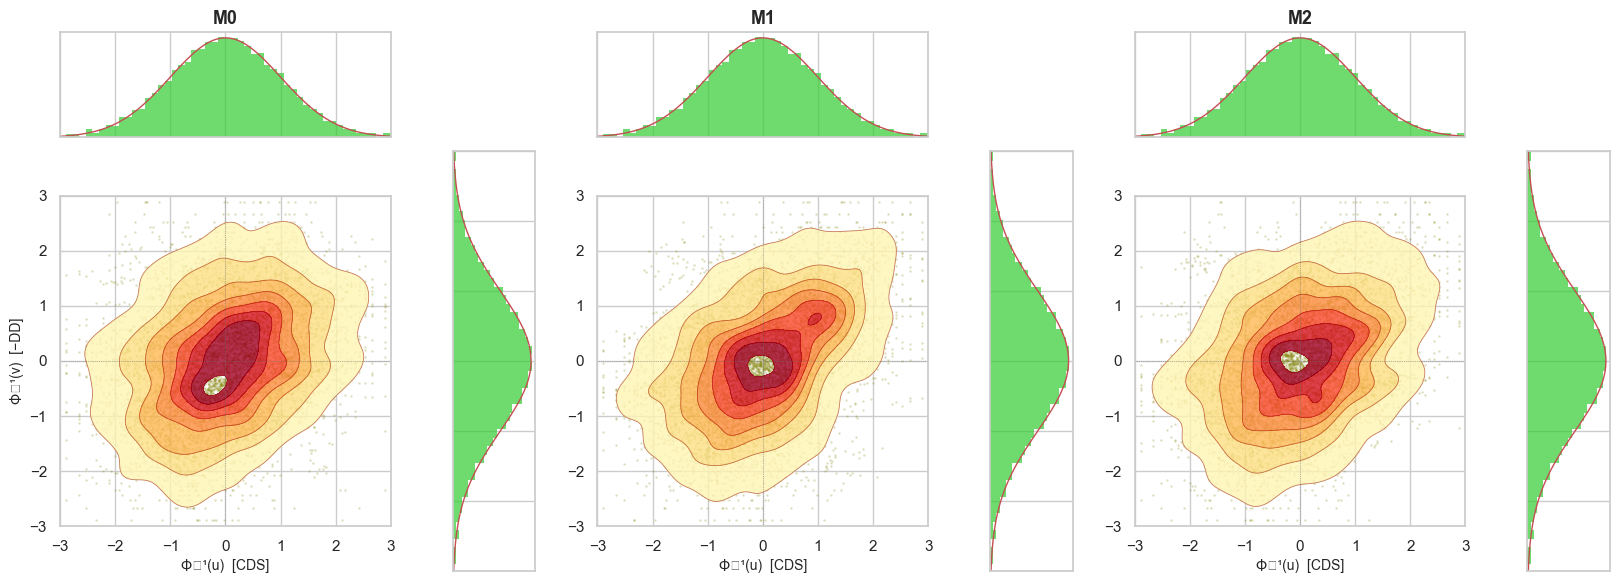

In [334]:
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(20, 7))
gs = GridSpec(2, 6, width_ratios=[4, 1, 4, 1, 4, 1], height_ratios=[1, 4],
              hspace=0.05, wspace=0.3)

for panel_idx, (model, dd_col) in enumerate([('M0', 'DD_M0'), ('M1', 'DD_M1'), ('M2', 'DD_M2')]):
    col_offset = panel_idx * 2
    ax_main = fig.add_subplot(gs[1, col_offset])
    ax_top = fig.add_subplot(gs[0, col_offset], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, col_offset + 1], sharey=ax_main)
    
    all_u, all_v = [], []
    for country in EXPORTERS + CONTROLS:
        sub = panel[panel[COUNTRY_COL] == country][[CDS_COL, dd_col]].dropna()
        sub = sub[sub[CDS_COL] > 0]
        u, v = country_margins_ecdf(sub[CDS_COL].values, sub[dd_col].values)
        all_u.extend(u)
        all_v.extend(v)
    
    u_arr = norm.ppf(np.clip(np.array(all_u), 0.001, 0.999))
    v_arr = norm.ppf(np.clip(np.array(all_v), 0.001, 0.999))
    
    # KDE contours
    kde = gaussian_kde(np.vstack([u_arr, v_arr]))
    grid = np.linspace(-3, 3, 150)
    X, Y = np.meshgrid(grid, grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    
    # Scatter
    ax_main.scatter(u_arr, v_arr, s=1, alpha=0.15, c='olive', zorder=1)
    # Filled contours
    levels = np.linspace(Z.max() * 0.05, Z.max() * 0.95, 8)
    ax_main.contourf(X, Y, Z, levels=levels, cmap='YlOrRd', alpha=0.8, zorder=2)
    ax_main.contour(X, Y, Z, levels=levels, colors='darkred', linewidths=0.6, alpha=0.5, zorder=3)
    
    ax_main.set_xlim(-3, 3)
    ax_main.set_ylim(-3, 3)
    ax_main.set_xlabel('Φ⁻¹(u)  [CDS]', fontsize=10)
    if panel_idx == 0:
        ax_main.set_ylabel('Φ⁻¹(v)  [−DD]', fontsize=10)
    ax_main.set_aspect('equal')
    ax_main.axhline(0, color='grey', ls=':', lw=0.5)
    ax_main.axvline(0, color='grey', ls=':', lw=0.5)
    
    # Top histogram
    ax_top.hist(u_arr, bins=50, color='limegreen', alpha=0.7, density=True, edgecolor='none')
    xg = np.linspace(-3, 3, 100)
    ax_top.plot(xg, norm.pdf(xg), 'r-', lw=1)
    ax_top.set_xlim(-3, 3)
    ax_top.tick_params(labelbottom=False)
    ax_top.set_yticks([])
    ax_top.set_title(f'{model}', fontsize=13, fontweight='bold')
    
    # Right histogram
    ax_right.hist(v_arr, bins=50, color='limegreen', alpha=0.7, density=True,
                  orientation='horizontal', edgecolor='none')
    ax_right.plot(norm.pdf(xg), xg, 'r-', lw=1)
    ax_right.set_ylim(-3, 3)
    ax_right.tick_params(labelleft=False)
    ax_right.set_xticks([])

plt.show()

In [339]:
def run_test_changes(target_model, copula_type):
    m0_col, mx_col = DD_COLS['M0'], DD_COLS[target_model]
    df = panel[[DATE_COL, COUNTRY_COL, CDS_COL, m0_col, mx_col, 'exporter']].dropna()
    df = df[df[CDS_COL] > 0].copy()
    df['d_loglik'] = np.nan

    for country in df[COUNTRY_COL].unique():
        mask = df[COUNTRY_COL] == country
        sub = df[mask].sort_values(DATE_COL).copy()
        
        dCDS = np.log(sub[CDS_COL]).diff()
        dDD0 = sub[m0_col].diff()
        dDD1 = sub[mx_col].diff()
        
        valid = dCDS.notna() & dDD0.notna() & dDD1.notna()
        if valid.sum() < 30:
            continue
        
        u = rankdata(dCDS[valid].values) / (valid.sum() + 1)
        v0 = rankdata(-dDD0[valid].values) / (valid.sum() + 1)
        v1 = rankdata(-dDD1[valid].values) / (valid.sum() + 1)
        
        if copula_type == 'student':
            p0 = fit_t_copula(u, v0)
            p1 = fit_t_copula(u, v1)
            ll0 = student_t_logpdf(u, v0, p0[0], p0[1])
            ll1 = student_t_logpdf(u, v1, p1[0], p1[1])

        elif copula_type == 'clayton':
            u_c = np.clip(1 - u, 1e-25, 1-1e-25)
            v0_c = np.clip(1 - v0, 1e-25, 1-1e-25)
            v1_c = np.clip(1 - v1, 1e-25, 1-1e-25)
            t0 = fit_clayton(u_c, v0_c)
            t1 = fit_clayton(u_c, v1_c)
            ll0 = clayton_logpdf(u_c, v0_c, t0)
            ll1 = clayton_logpdf(u_c, v1_c, t1)

        elif copula_type == 'gaussian':
            r0 = fit_gaussian(u, v0)
            r1 = fit_gaussian(u, v1)
            ll0 = gaussian_logpdf(u, v0, r0)
            ll1 = gaussian_logpdf(u, v1, r1)

        elif copula_type == 'gumbel':
            t0 = fit_gumbel(u, v0)
            t1 = fit_gumbel(u, v1)
            ll0 = gumbel_logpdf(u, v0, t0)
            ll1 = gumbel_logpdf(u, v1, t1)

        elif copula_type == 'joe':
            t0 = fit_joe(u, v0)
            t1 = fit_joe(u, v1)
            ll0 = joe_logpdf(u, v0, t0)
            ll1 = joe_logpdf(u, v1, t1)
        
        idx = df.index[mask][valid]
        df.loc[idx, 'd_loglik'] = ll1 - ll0

    clean = df.dropna(subset=['d_loglik'])
    q = clean['d_loglik'].quantile([0.01, 0.99])
    clean['d_loglik'] = clean['d_loglik'].clip(q[0.01], q[0.99])
    X = sm.add_constant(clean['exporter'])
    res = sm.OLS(clean['d_loglik'], X).fit(cov_type='HAC',
          cov_kwds={'maxlags': None, 'kernel': 'bartlett', 'use_correction': True})
    return res

for model, cop in [('M1', 'gaussian'), ('M2', 'gaussian'), ('M1', 'gumbel'), ('M2', 'gumbel'), ('M1', 'clayton'), ('M2', 'clayton'), ('M1', 'student'), ('M2', 'student'), ('M1','joe'), ('M2', 'joe')]:
    res = run_test_changes(model, cop)
    dw = durbin_watson(res.resid)
    print(f"\n{model} ({cop}) CHANGES: DW = {dw:.3f}")
    print(f"  Gamma (Universal): {res.params['const']:.4f} (p={res.pvalues['const']:.4f})")
    print(f"  Delta (Exporter):  {res.params['exporter']:.4f} (p={res.pvalues['exporter']:.4f})")


M1 (gaussian) CHANGES: DW = 1.908
  Gamma (Universal): -0.0018 (p=0.2393)
  Delta (Exporter):  0.0047 (p=0.0237)

M2 (gaussian) CHANGES: DW = 1.888
  Gamma (Universal): 0.0079 (p=0.0001)
  Delta (Exporter):  0.0097 (p=0.0048)

M1 (gumbel) CHANGES: DW = 1.915
  Gamma (Universal): -0.0024 (p=0.2472)
  Delta (Exporter):  0.0045 (p=0.0955)

M2 (gumbel) CHANGES: DW = 1.877
  Gamma (Universal): 0.0086 (p=0.0000)
  Delta (Exporter):  0.0103 (p=0.0041)

M1 (clayton) CHANGES: DW = 1.919
  Gamma (Universal): -0.0041 (p=0.0628)
  Delta (Exporter):  0.0054 (p=0.0656)

M2 (clayton) CHANGES: DW = 1.906
  Gamma (Universal): 0.0087 (p=0.0000)
  Delta (Exporter):  0.0102 (p=0.0030)

M1 (student) CHANGES: DW = 1.923
  Gamma (Universal): -0.0009 (p=0.5705)
  Delta (Exporter):  0.0043 (p=0.0501)

M2 (student) CHANGES: DW = 1.886
  Gamma (Universal): 0.0079 (p=0.0001)
  Delta (Exporter):  0.0099 (p=0.0038)

M1 (joe) CHANGES: DW = 1.925
  Gamma (Universal): -0.0144 (p=0.1472)
  Delta (Exporter):  0.0219 (p